Duilio Lucio, Vivian Hu

Spring 2026

CS343: Neural Networks

Project 3: Convolutional Neural Networks

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=7)

# Automatically reload your external source code
%load_ext autoreload
%autoreload 2

## ConvNet4V2: Taking ConvNet4 even farther

This week, you will explore two changes to ConvNet4 that may improve its classification accuracy and help guard against overfitting:

1. Adding a Dropout Layer to the ConvNet4 architecture, creating a new `ConvNet4V2` network.
2. Training with regularization and the AdamW optimizer.

Each of the forthcoming tasks focuses on implementing the above items then running a computational experiment to characterize any improvements they may offer.

## Task 9: Dropout

### Task 9a: Implement the Dropout Layer

Start by implementing and testing the `Dropout` class in `layer.py`.

In [7]:
from layer import Dropout

#### (i) Test Dropout forward pass

In [8]:
rng = np.random.default_rng(1)
inputs = rng.normal(loc=0, scale=0.25, size=(5, 3))

d_layer = Dropout(3, 'Drop', rate=0.8, r_seed=2)
print('Test: 1/2 (prediction):')
drop_netact = d_layer.forward(inputs.copy())
print('Your dropout netact:\n', drop_netact)
print('It should be:')
print(''' [[ 0.086396   0.2054045  0.0826093]
 [-0.3257893  0.226339   0.1115936]
 [-0.1342383  0.1452795  0.0911431]
 [ 0.0735331  0.0071056  0.1366782]
 [-0.1841135 -0.0407275 -0.1205298]]''')

Test: 1/2 (prediction):
Your dropout netact:
 [[ 0.086396   0.2054045  0.0826093]
 [-0.3257893  0.226339   0.1115936]
 [-0.1342383  0.1452795  0.0911431]
 [ 0.0735331  0.0071056  0.1366782]
 [-0.1841135 -0.0407275 -0.1205298]]
It should be:
 [[ 0.086396   0.2054045  0.0826093]
 [-0.3257893  0.226339   0.1115936]
 [-0.1342383  0.1452795  0.0911431]
 [ 0.0735331  0.0071056  0.1366782]
 [-0.1841135 -0.0407275 -0.1205298]]


In [9]:
print('Test: 2/2 (training):')
d_layer = Dropout(3, 'Drop', rate=0.8, r_seed=2)
d_layer.set_training_mode(True)
drop_netact = d_layer.forward(inputs.copy())
d_layer.set_training_mode(False)
print('Your dropout netact:\n', drop_netact)
print()
print('Depending on your implementation, your net_act above should only match ONE of the following options:')

print('OPTION 1:')
print(''' [[ 0.         0.         0.       ]
 [-0.         1.1316948  0.       ]
 [-0.         0.7263976  0.4557155]
 [ 0.         0.         0.       ]
 [-0.        -0.        -0.       ]]''')

print('\nOPTION 2:')
print(''' [[ 0.4319802  1.0270227  0.       ]
 [-0.         0.         0.       ]
 [-0.         0.         0.       ]
 [ 0.3676656  0.         0.       ]
 [-0.        -0.2036374 -0.6026491]]''')


Test: 2/2 (training):
Your dropout netact:
 [[ 0.         0.         0.       ]
 [-0.         1.1316948  0.       ]
 [-0.         0.7263976  0.4557155]
 [ 0.         0.         0.       ]
 [-0.        -0.        -0.       ]]

Depending on your implementation, your net_act above should only match ONE of the following options:
OPTION 1:
 [[ 0.         0.         0.       ]
 [-0.         1.1316948  0.       ]
 [-0.         0.7263976  0.4557155]
 [ 0.         0.         0.       ]
 [-0.        -0.        -0.       ]]

OPTION 2:
 [[ 0.4319802  1.0270227  0.       ]
 [-0.         0.         0.       ]
 [-0.         0.         0.       ]
 [ 0.3676656  0.         0.       ]
 [-0.        -0.2036374 -0.6026491]]


#### (ii) Test Dropout backward pass

In [10]:
rng = np.random.default_rng(1)
inputs = rng.normal(loc=0, scale=0.25, size=(5, 3))
d_upstream = rng.uniform(low=0, high=0.5, size=(5, 3))

# Test 1
d_layer = Dropout(3, 'Drop', rate=0.8, r_seed=2)
d_layer.set_training_mode(True)
drop_netact = d_layer.forward(inputs)
d_prev, _, _ = d_layer.backward_netIn_to_prevLayer_netAct(d_upstream)
d_layer.set_training_mode(False)
print('Your dropout d_prev:\n', d_prev)
print()
print('Depending on your implementation, your net_act above should only match ONE of the following pairs:')

print('OPTION 1:')
print(''' [[0.        0.        0.       ]
 [0.        0.6557834 0.       ]
 [0.        1.2129774 2.451843 ]
 [0.        0.        0.       ]
 [0.        0.        0.       ]]''')

print('\nOPTION 2:')
print(''' [[1.1337447 0.3351042 0.       ]
 [0.        0.        0.       ]
 [0.        0.        0.       ]
 [2.404143  0.        0.       ]
 [0.        0.40163   2.4248135]]''')

Your dropout d_prev:
 [[0.        0.        0.       ]
 [0.        0.6557834 0.       ]
 [0.        1.2129774 2.451843 ]
 [0.        0.        0.       ]
 [0.        0.        0.       ]]

Depending on your implementation, your net_act above should only match ONE of the following pairs:
OPTION 1:
 [[0.        0.        0.       ]
 [0.        0.6557834 0.       ]
 [0.        1.2129774 2.451843 ]
 [0.        0.        0.       ]
 [0.        0.        0.       ]]

OPTION 2:
 [[1.1337447 0.3351042 0.       ]
 [0.        0.        0.       ]
 [0.        0.        0.       ]
 [2.404143  0.        0.       ]
 [0.        0.40163   2.4248135]]


### 9b. Create ConvNet4AccelV2 network

1. Create a new class in `network.py` called `ConvNet4AccelV2` that is the same as `ConvNet4Accel` except that we now add a single dropout layer before the output layer. The layers of your network should now look like:

Conv2D → MaxPool2D → Flatten → Dense → **Dropout** → Dense

2. The `ConvNet4AccelV2` constructor should have all the same method parameters as `ConvNet4Accel`, except you should add a `dropout_rate` parameter with the default value of `0.0`.

In [11]:
from network import ConvNet4AccelV2

### 9c. Update Network class to support Dropout

Make the following updates to your `Network` class methods to support Dropout layers, which behave differently when training vs when in test/prediction/evaluation/inference mode.

#### Train/test mode setting methods

Implement the following short methods.
1. `is_training` (`Network`)
2. `set_training_mode` (`Network`) 
3. `set_training_mode` (`Layer`)

##### predict

1. Before doing the forward pass, set the layers to operate in test/prediction/evaluation/inference mode.
2. After doing the forward pass, set the layers to operate in whatever mode they were at the start
of this method.

##### train

When starting the training session:
- Set the network to training mode.
- Set all the network layers to operate in training mode.

When the training session ends:
- Set the network to not be in training mode.
- Set all the network layers to not be in training mode.

### 9d. Analyze effect of dropout on STL-10 loss and accuracy

Run an experiment in which you train four separate `ConvNet4AccelV2` nets, each with the same default hyperparameters except set the dropout rates to be `[0.0, 0.1, 0.5, 0.9]`, respectively. For example, the first net should have `0.0` dropout, the 2nd should have `0.1` dropout, etc. 

Create two high quality plots showing the:
1. training loss over training iterations.
2. test accuracy achieved after training with the different dropout rates. *This means your x-axis should correspond to dropout rate, NOT epochs/iterations.*

produced by each network.

**Training notes:**
- Use the optimizer that you found performs best from above.
- Use a random seed of `0` in all your nets.
- You should be able to keep most/all hyperparameters to their default values for this experiment.
- Training for `15` epochs should be enough to produce the expected pattern of results. This means that the experiment should take only a few minutes to run.

If everything is working properly, you should find that at least one of the nonzero dropout settings yields better test accuracy.

In [12]:
import load_stl10_dataset
import preprocess_data

In [13]:
# Download the STL-10 dataset from the internet, convert it to Numpy ndarray, resize to 32x32
# cache it locally on your computer for faster loading next time.
load_stl10_dataset.purge_cached_dataset()
# preprocess and create splits
x_train, y_train, x_test, y_test, x_val, y_val, x_dev, y_dev = preprocess_data.load_stl10(
    n_train_samps=4000, n_test_samps=500, n_valid_samps=499, n_dev_samps=1, scale_fact=3)

print ('Train data shape: ', x_train.shape)
print ('Train labels shape: ', y_train.shape)
print ('Test data shape: ', x_test.shape)
print ('Test labels shape: ', y_test.shape)
print ('Validation data shape: ', x_val.shape)
print ('Validation labels shape: ', y_val.shape)
print ('dev data shape: ', x_dev.shape)
print ('dev labels shape: ', y_dev.shape)

Extracting ./data/stl10_binary.tar.gz...Done!
Images are: (5000, 96, 96, 3)
Labels are: (5000,)
Resizing 5000 images to 32x32...Done!
Saving Numpy arrays the images and labels to ./numpy...Done!
Train data shape:  (4000, 3, 32, 32)
Train labels shape:  (4000,)
Test data shape:  (500, 3, 32, 32)
Test labels shape:  (500,)
Validation data shape:  (499, 3, 32, 32)
Validation labels shape:  (499,)
dev data shape:  (1, 3, 32, 32)
dev labels shape:  (1,)


Starting Dropout Experiment...

--- Training with dropout_rate = 0.0 ---
Iteration 0: computing timing estimates...
[Iter 0/75] Loss: 2.3250, Train Acc: 0.104, Val Acc: 0.100
Elapsed: 0.08m, Projected total: 6.09m
[Iter 25/75] Loss: 1.6832, Train Acc: 0.388, Val Acc: 0.385
[Iter 50/75] Loss: 1.3800, Train Acc: 0.564, Val Acc: 0.437
[Iter 75/75] Loss: 1.1130, Train Acc: 0.624, Val Acc: 0.457
Test accuracy for dropout_rate 0.0: 0.492

--- Training with dropout_rate = 0.1 ---
Iteration 0: computing timing estimates...
[Iter 0/75] Loss: 2.3249, Train Acc: 0.102, Val Acc: 0.098
Elapsed: 0.02m, Projected total: 1.56m
[Iter 25/75] Loss: 1.6674, Train Acc: 0.400, Val Acc: 0.349
[Iter 50/75] Loss: 1.4162, Train Acc: 0.526, Val Acc: 0.421
[Iter 75/75] Loss: 1.1566, Train Acc: 0.608, Val Acc: 0.413
Test accuracy for dropout_rate 0.1: 0.500

--- Training with dropout_rate = 0.5 ---
Iteration 0: computing timing estimates...
[Iter 0/75] Loss: 2.3238, Train Acc: 0.112, Val Acc: 0.108
Elapsed: 0.01m,

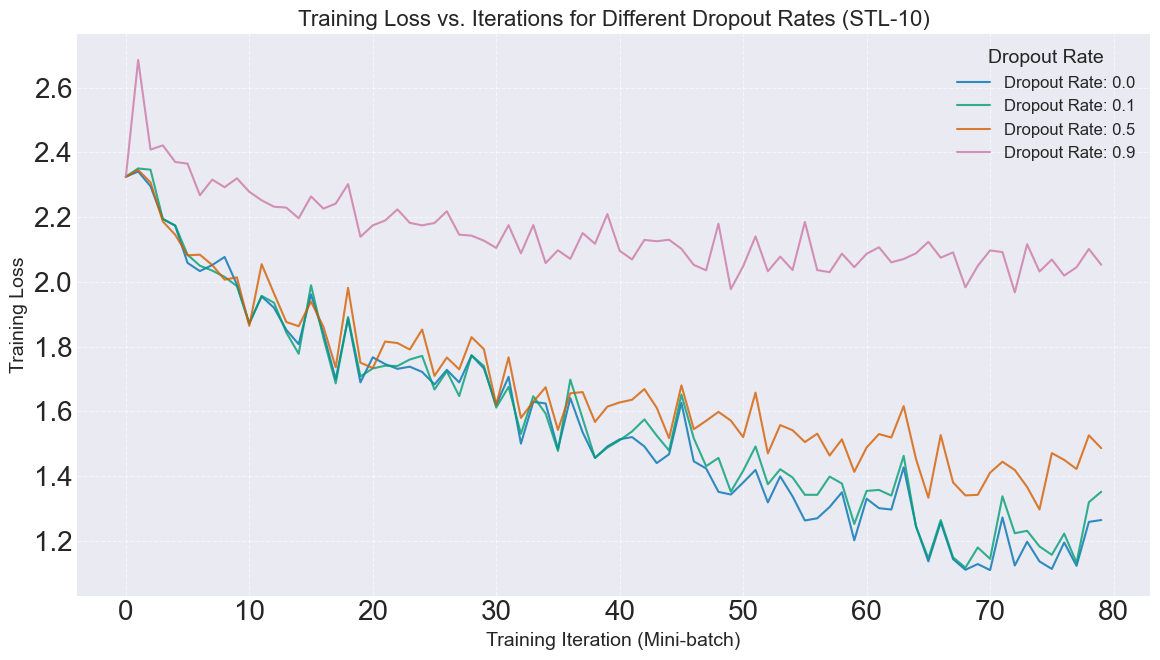

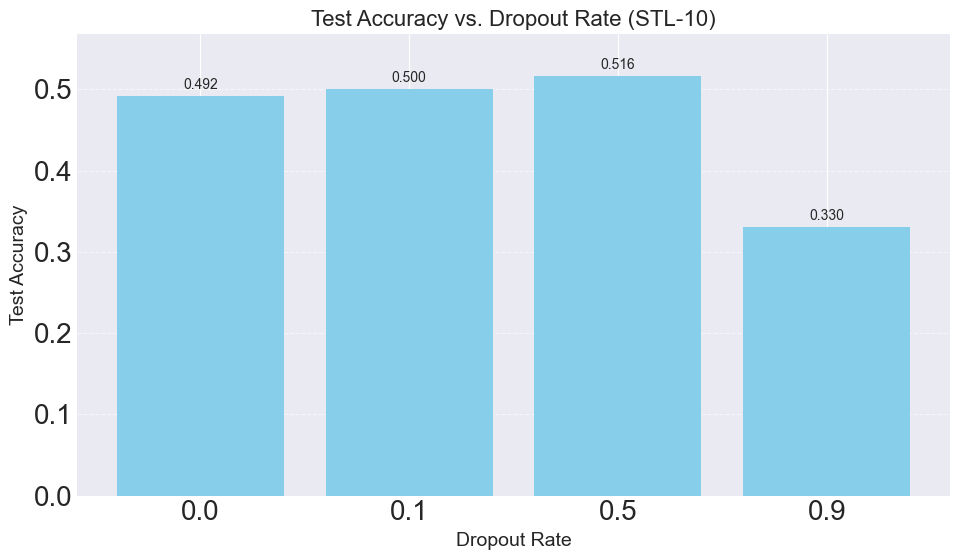

In [16]:
# YOUR CODE HERE
# running 4 nets and comparing the difference in performance 

# specifying the 4 parameters to test with 
dropout_rates = [0.0, 0.1, 0.5, 0.9]
loss_histories = {}
test_accuracies = {}

# best optimizers from above was Adam, with our best learning rate around 3e-3
OPTIMIZER_NAME = 'adam'
LEARNING_RATE = 3e-3

# fixed hyperparameters for new nets 
NET_PARAMS = {
    'input_shape': (3, 32, 32),
    'n_kers': (64,),
    'ker_sz': (5,),
    'dense_interior_units': (256,),
    'pooling_sizes': (2,),
    'pooling_strides': (2,),
    'n_classes': 10,
    'wt_scale': 1e-2,
    'reg': 1e-4,
    'r_seed': 0, # using a fixed random seed for reproducibility
    'verbose': False
}

TRAIN_PARAMS = {
    'mini_batch_sz': 256,
    'n_epochs': 5,
    'print_every': 25 
}

print("Starting Dropout Experiment...")
for rate in dropout_rates:
    print(f"\n--- Training with dropout_rate = {rate} ---")
    
    # creating ConvNet4AccelV2 net with specified dropout rates above
    net = ConvNet4AccelV2(**NET_PARAMS, dropout_rate=rate)
    
    # compiling with Adam optimizer
    net.compile(OPTIMIZER_NAME, lr=LEARNING_RATE)
    
    # training on training set, validating on val set
    current_loss_hist, _, _ = net.fit(
        x_train=x_train, y_train=y_train,
        x_validate=x_val, y_validate=y_val,
        **TRAIN_PARAMS
    )
    
    loss_histories[rate] = current_loss_hist
    
    # calculating test accuracy
    current_test_acc = net.accuracy(x_test, y_test, samp_sz=len(x_test), mini_batch_sz=TRAIN_PARAMS['mini_batch_sz'])
    test_accuracies[rate] = current_test_acc
    print(f"Test accuracy for dropout_rate {rate}: {current_test_acc:.3f}")

print("\nExperiment Finished.")

# these are my plots now 

# first plot, training Loss over Training Iterations
plt.figure(figsize=(12, 7))
for rate, history in loss_histories.items():
    # loss is recorded for every iteration 
    iterations = np.arange(len(history))
    plt.plot(iterations, history, label=f'Dropout Rate: {rate}', alpha=0.8)

plt.title('Training Loss vs. Iterations for Different Dropout Rates (STL-10)', fontsize=16)
plt.xlabel('Training Iteration (Mini-batch)', fontsize=14)
plt.ylabel('Training Loss', fontsize=14)
plt.legend(title='Dropout Rate', fontsize=12, title_fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# second plot: Test Accuracy vs. Dropout Rate
plt.figure(figsize=(10, 6))
rates = list(test_accuracies.keys())
accuracies = list(test_accuracies.values())

plt.bar(range(len(rates)), accuracies, tick_label=[str(r) for r in rates], color='skyblue')
# adding accuracy values on top of bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

plt.title('Test Accuracy vs. Dropout Rate (STL-10)', fontsize=16)
plt.xlabel('Dropout Rate', fontsize=14)
plt.ylabel('Test Accuracy', fontsize=14)
plt.ylim(0, max(accuracies) * 1.1) # set y axis limits for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 9c. Questions

**Question 7:** What is the relationship between dropout and your training loss? Based on this, how would you expect the validation loss to look for the different dropout levels?

*There's no need to actually check the val loss here, this question is asking about your expectations based on your training loss results. You can check / do a deeper analysis for an extension (if you like).*

**Question 8:** How does the dropout rate appear to effect your test accuracy?

**Answer 7:** 

Higher dropout rates lead to higher training loss, with rate=0.9 barely decreasing from ~2.3, while rate = 0.0 and rate = 0.1 reaching ~1.2. Which is expected since dropout disables neurons each iteration, making it harder to fit training data. For val loss, one would expect modereate dropsout rates (0.1, 0.5) to produce smallest train/val gap since regularization reduces overfitting. Rate = 0.0 would also have the largest gap (having the best training loss but worse generalization), and rate = 0.9 would have high val loss only because the network barely learned anything.

**Answer 8:** 

Moderate dropout clearly improves test accuracy over no dropout, rate = 0.5 achieved the best result at 51.6% followed by rate = 0.1 at 50.0%, both beating rate = 0.0 baseline of 49.2%. Rate = 0.9 collapsed to 33% because dropping 90% of neurons is too aggressive for the network to learn meaningful features in 5 epochs. Pattern confirms that dropout helps generalization up to a point, after which it becomes destructive.

## Task 10: Adam vs AdamW and weight decay

In this task, you will compare how the Adam and AdamW optimizers handle regularization.

### 10a. Implement and test AdamW

Create a new `AdamW` class in `optimizers.py` by copy-pasting the contents of your `Adam` class and add/change very few lines of code. This should be a very quick implementation. Review your class notes for the implementation strategy.

**Note:** You will need to change something about the constructor compared to Adam...

####  Test AdamW

In [17]:
from optimizer import AdamW

In [19]:
rng = np.random.default_rng(0)

wts = rng.standard_normal((3, 4))
d_wts = rng.standard_normal((3, 4))

opt = AdamW(lr=0.1, reg=0)
opt.prepare(wts, d_wts)

new_wts_1 = opt.update_weights()
new_wts_2 = opt.update_weights()
new_wts_3 = opt.update_weights()

print('Test 1/2 (no reg):')
print(f'AdamW: Wts after 1 iter\n{new_wts_1}')
print(f'AdamW: Wts after 2 iter\n{new_wts_2}')
print(f'AdamW: Wts after 3 iter\n{new_wts_3}')
print(45*'-')

opt = AdamW(lr=0.1, reg=0.1)
opt.prepare(wts, d_wts)

new_wts_1 = opt.update_weights()
new_wts_2 = opt.update_weights()
new_wts_3 = opt.update_weights()

print('Test 2/2 (w/ reg):')
print(f'AdamW: Wts after 1 iter\n{new_wts_1}')
print(f'AdamW: Wts after 2 iter\n{new_wts_2}')
print(f'AdamW: Wts after 3 iter\n{new_wts_3}')

Test 1/2 (no reg):
AdamW: Wts after 1 iter
[[ 0.2257302 -0.0321049  0.7404226  0.2049001]
 [-0.4356694  0.4615951  1.204      0.847081 ]
 [-0.6037352 -1.3654215 -0.5232745 -0.058674 ]]
AdamW: Wts after 2 iter
[[ 0.3257302  0.0678951  0.8404226  0.3049001]
 [-0.3356694  0.561595   1.104      0.747081 ]
 [-0.5037353 -1.4654215 -0.4232745 -0.158674 ]]
AdamW: Wts after 3 iter
[[ 0.4257302  0.1678951  0.9404226  0.4049001]
 [-0.2356694  0.661595   1.0040001  0.647081 ]
 [-0.4037353 -1.5654215 -0.3232745 -0.258674 ]]
---------------------------------------------
Test 2/2 (w/ reg):
AdamW: Wts after 1 iter
[[ 0.2244729 -0.0307838  0.7340184  0.2038511]
 [-0.4303127  0.4579791  1.19096    0.8376102]
 [-0.5966979 -1.3527673 -0.5170417 -0.0590873]]
AdamW: Wts after 2 iter
[[ 0.3222282  0.069524   0.8266782  0.3018126]
 [-0.3260096  0.5533993  1.0790504  0.7292341]
 [-0.4907309 -1.4392396 -0.4118713 -0.1584964]]
AdamW: Wts after 3 iter
[[ 0.4190059  0.1688288  0.9184115  0.3987945]
 [-0.2227495  0

You should see:

        Test 1/2 (no reg):
        AdamW: Wts after 1 iter
        [[ 0.2257302 -0.0321049  0.7404226  0.2049001]
        [-0.4356694  0.4615951  1.204      0.847081 ]
        [-0.6037352 -1.3654215 -0.5232745 -0.058674 ]]
        AdamW: Wts after 2 iter
        [[ 0.3257302  0.0678951  0.8404226  0.3049001]
        [-0.3356694  0.561595   1.104      0.747081 ]
        [-0.5037353 -1.4654215 -0.4232745 -0.158674 ]]
        AdamW: Wts after 3 iter
        [[ 0.4257302  0.1678951  0.9404226  0.4049001]
        [-0.2356694  0.661595   1.0040001  0.647081 ]
        [-0.4037353 -1.5654215 -0.3232745 -0.258674 ]]
        ---------------------------------------------
        Test 2/2 (w/ reg):
        AdamW: Wts after 1 iter
        [[ 0.2244729 -0.0307838  0.7340184  0.2038511]
        [-0.4303127  0.4579791  1.19096    0.8376102]
        [-0.5966979 -1.3527673 -0.5170417 -0.0590873]]
        AdamW: Wts after 2 iter
        [[ 0.322239   0.0696204  0.8266962  0.3018449]
        [-0.3259598  0.5534605  1.0789672  0.7292058]
        [-0.4906463 -1.4392544 -0.4118296 -0.1585605]]
        AdamW: Wts after 3 iter
        [[ 0.419045   0.1691759  0.9184766  0.3989116]
        [-0.2225696  0.6480865  0.9679598  0.6218391]
        [-0.3854627 -1.5249009 -0.3076015 -0.257143 ]]

### 10b. Compare Adam and AdamW

Below, train separate `ConvNet4AccelV2` nets with separate 4 regularization strengths `[0, 0.01, 0.1, 0.5]`. As in your dropout experiment, each net should use a different regularization value. In each case, train the net once with Adam and once again with AdamW. Compute/keep track of the test accuracy achieved by each net on STL-10.

Default hyperparameters (including learning rate) should be fine, except:
- For consistency, you a random seed of `0` in all nets.
- Train the networks for `10` epochs.
- Make sure the dropout rate is set to `0.0` (the default) so that this experiment focuses the effect on regularization only.

Create a single high-quality plot showing the test accuracy achieved after training with the different regularization strengths and optimizers (i.e. 2 curves, 4 plot markers each).

**Hint:** When you compile your network with AdamW, you should need to pass something else into `compile` aside from the optimizer name that is not the learning rate...


In [21]:
# YOUR CODE HERE
reg_strengths = [0, 0.01, 0.1, 0.5]

adam_test_accs  = []
adamw_test_accs = []

NET_PARAMS = {
    'input_shape': (3, 32, 32),
    'n_kers': (64,),
    'ker_sz': (5,),
    'dense_interior_units': (256,),
    'pooling_sizes': (2,),
    'pooling_strides': (2,),
    'n_classes': 10,
    'wt_scale': 1e-2,
    'dropout_rate': 0.0,   # isolated to regularization only
    'r_seed': 0,
    'verbose': False
}

TRAIN_PARAMS = {
    'x_train': x_train, 'y_train': y_train,
    'x_validate': x_val, 'y_validate': y_val,
    'mini_batch_sz': 256,
    'n_epochs': 10,
    'print_every': 50
}

print("Starting Adam vs AdamW Experiment...")

for reg in reg_strengths:
    print(f'\n--- reg = {reg} ---')

    # --- Adam ---
    net_adam = ConvNet4AccelV2(**NET_PARAMS, reg=reg)
    net_adam.compile('adam', lr=3e-3)          # Adam: reg is handled by L2 inside layers
    net_adam.fit(**TRAIN_PARAMS)
    acc_adam = net_adam.accuracy(x_test, y_test, samp_sz=len(x_test), mini_batch_sz=256)
    adam_test_accs.append(acc_adam)
    print(f'  Adam  test acc: {acc_adam:.3f}')

    # --- AdamW ---
    net_adamw = ConvNet4AccelV2(**NET_PARAMS, reg=0)  # reg=0 in network — AdamW handles decay itself
    net_adamw.compile('adamw', lr=3e-3, reg=reg)      # reg passed into AdamW constructor via compile
    net_adamw.fit(**TRAIN_PARAMS)
    acc_adamw = net_adamw.accuracy(x_test, y_test, samp_sz=len(x_test), mini_batch_sz=256)
    adamw_test_accs.append(acc_adamw)
    print(f'  AdamW test acc: {acc_adamw:.3f}')

print('\nExperiment Finished.')

Starting Adam vs AdamW Experiment...

--- reg = 0 ---
Iteration 0: computing timing estimates...
[Iter 0/150] Loss: 2.3041, Train Acc: 0.104, Val Acc: 0.100
Elapsed: 0.03m, Projected total: 5.03m
[Iter 50/150] Loss: 1.3609, Train Acc: 0.524, Val Acc: 0.445
[Iter 100/150] Loss: 0.7306, Train Acc: 0.758, Val Acc: 0.471
[Iter 150/150] Loss: 0.2920, Train Acc: 0.942, Val Acc: 0.463
  Adam  test acc: 0.516
Iteration 0: computing timing estimates...
[Iter 0/150] Loss: 2.3041, Train Acc: 0.104, Val Acc: 0.100
Elapsed: 0.04m, Projected total: 5.37m
[Iter 50/150] Loss: 1.3609, Train Acc: 0.524, Val Acc: 0.445
[Iter 100/150] Loss: 0.7306, Train Acc: 0.758, Val Acc: 0.471
[Iter 150/150] Loss: 0.2920, Train Acc: 0.942, Val Acc: 0.463
  AdamW test acc: 0.516

--- reg = 0.01 ---
Iteration 0: computing timing estimates...
[Iter 0/150] Loss: 4.4027, Train Acc: 0.150, Val Acc: 0.150
Elapsed: 0.02m, Projected total: 2.61m
[Iter 50/150] Loss: 1.7173, Train Acc: 0.488, Val Acc: 0.397
[Iter 100/150] Loss: 

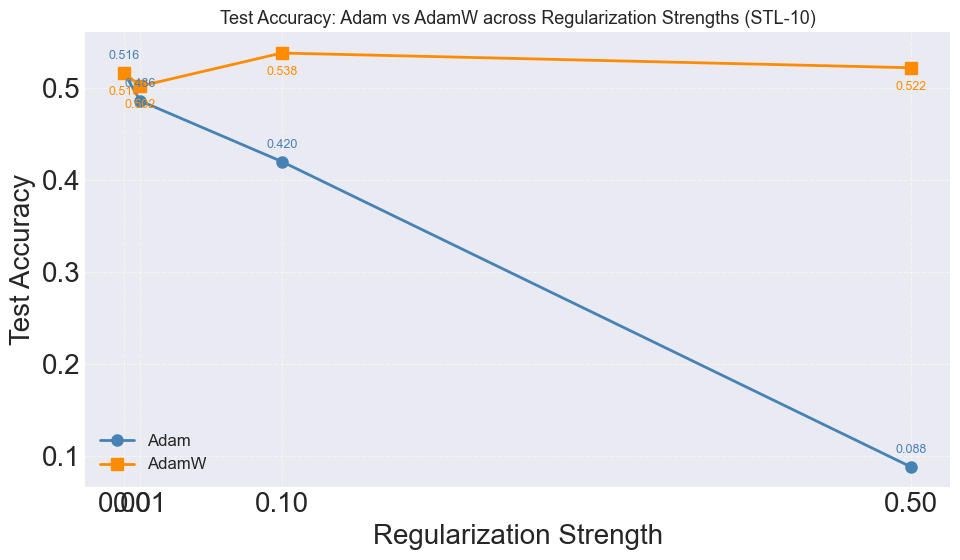

In [22]:
# Plot
plt.figure(figsize=(10, 6))

plt.plot(reg_strengths, adam_test_accs,  label='Adam',  color='steelblue',
         linewidth=2, marker='o', markersize=8)
plt.plot(reg_strengths, adamw_test_accs, label='AdamW', color='darkorange',
         linewidth=2, marker='s', markersize=8)

# Annotate each point with its value
for reg, acc in zip(reg_strengths, adam_test_accs):
    plt.annotate(f'{acc:.3f}', xy=(reg, acc), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=9, color='steelblue')
for reg, acc in zip(reg_strengths, adamw_test_accs):
    plt.annotate(f'{acc:.3f}', xy=(reg, acc), xytext=(0, -16),
                 textcoords='offset points', ha='center', fontsize=9, color='darkorange')

plt.title('Test Accuracy: Adam vs AdamW across Regularization Strengths (STL-10)', fontsize=13)
plt.xlabel('Regularization Strength')
plt.ylabel('Test Accuracy')
plt.xticks(reg_strengths)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('adam_vs_adamw.png', dpi=150, bbox_inches='tight')
plt.show()

### 10c. Questions

**Question 9:** Interpret the results of your regularization experiment. Is this what you expected would happen?

**Answer 9:** 

Adam degrades sharply as regularization increases from 51.6% at regularization=0 down to just 8.8% at regularization = 0.5. This occurs since Adam's L2 regularization adds regularization * weights directly to the gradient before the adaptive scaling step. At high regularization strengths the adaptive learning rates amplify the decay term unevenly across parameters, causing some weights to shrink far too aggressively and destroy what the network learned.

AdamW stays remarkably stable across all regularization strengths ranging from 51.6% to 53.8% and constantly overperforms Adam at every nonzero regularization level. This is expected since AdamW's decoupled weight decay applies to penalty after and independent of the adaptive step, meaning every weight decays proportionally to its value regardless of gradieent history. Regularization stays predictable and well-behaved even at regularization = 0.5.

The fact that both optimizers produce identical results at reg=0 is also expected there is no regularization, AdamW's weight decay term is zero and the two update rules are mathematically identical, confirming the implementation is correct.

Overall, AdamW is the clearly superior choice when regularization is needed, which aligns with why it has largely replaced Adam as the default optimizer in modern deep learning.

## Extensions

### General guidelines

1. Never integrate extensions into your base project so that they change the expected behavior of core functions. If your extension changes the core design/behavior, no problem, duplicate your working base project and add features from there.
2. Check the rubric to keep in mind how extensions on this project will be graded.
3. While I may consult your code and "written log" of what you did, **I am grading your extensions based on what you present in your 3-5 min video.**
3. I suggest documenting your explorations in a "log" or "lab notebook" style (i.e. documenting your thought/progression/discovery/learning process). I'm not grading your writing, so you can keep it succinct. **Whatever is most useful to you to remember what you did.** 
4. I suggest taking a hypothesis driven approach. For example "I was curious about X so I explored Y. I found Z, which was not what I expected because..., so then tried A..."
5. Make plots to help showcase your results.
6. **More is not necessarily better.** Generally, a small number of "in-depth" extensions count for more than many "shallow" extensions.

### AI guidelines

You may use AI in mostly any capacity for extensions. However, keep in mind:
1. There is no need to use AI at all!
2. You are welcome to use AI as a tool (e.g. automate something that is tedious, help you get unstuck, etc.). However, you should be coding, you should be thinking, you should be writing, you should be creating. If you are spending most (or even close to most) of your time typing into a chatbot and copy-pasting, you have probably gone too far with AI use.
3. I don't find large volumes of AI generated code/text/plots to be particularly impressive and you risk losing my interest while grading. Remember: I'm grading your extensions based on your video presentation. **More is not necessarily better.**

### Video guidelines

1. Please try to keep your video to 5 minutes (*I have other projects to grade!*). If you turn in a longer video, I make no promise that I will watch more than 5 minutes.
2. Your screen should be shared as you show me what you did. A live video of your face should also appear somewhere on the screen (e.g. picture-in-picture overlay / split screen).
3. Your partner should join you for the video and take turns talking, but, if necessary, it is fine to have one team member present during the record the video.
4. Do not simply read text from your notebook, do not read from a prepared script. I am not grading how polished your video presentation is (see extension grading criteria on rubric). 
5. I am looking for original and creative explorations sparked by your curiosity/interest/passion in a topic. This should be apparent in your video.
6. Be natural,, don't feel the need to impress me with fancy language. If it is helpful, imagine that we are talking one-on-one about your extension. Tell me what you did :)

### Extension ideas

#### 0. Pedal to the metal: achieve high accuracy on STL-10

You can achieve higher (>50%) classification accuracy on the STL-10 test set. Find the hyperparameters to achieve this. You can use random, grid search, or simply hand tuning (trial and error) — keep in mind that even with the accelerated layers, each training run may take minutes (or longer) to complete.

#### 1. Experiment with different network architectures.

The design of the `Network` class is modular. As long as you're careful about shapes, adding/removing network layers (e.g. `Conv2D`, `Dense`, etc.) should be straight forward. Experiment with adding another sequence of `Conv2D` and `MaxPool2D` layers. Add another `Dense` hidden layer before the output layer. Add additional dropout layers in between `Dense` layers (or around `Conv2D`/`MaxPool2D` if can get your implementation to support it). How do the changes affect classification accuracy and loss? 

#### 2. Experiment with different network hyperparameters.

Explore the affect one or more change below has on classification. Be careful about how the hyperparameters may affect the shape of network layers. Thorough analysis will get you more points (not try a few ad hoc values).

- Experiment with different numbers of hidden units in the Dense layers.
- Experiment different max pooling window sizes and strides.
- Experiment with kernel sizes (not 7x7). Can you get away with smaller ones? Do they perform just as well? What is the change in runtime like? What is the impact on their visualized appearance?
- Experiment with number of kernels in the convolutional layer. Is more/fewer better? What is the impact on their visualized appearance?

#### 3. Different hidden layer activation functions

Implement and experiment with activation functions that are appropriate for hidden layers (e.g. Leaky ReLU, ELU, SELU, GELU, Sigmoid, Softplus, Mish, etc.). How do they affect speed of training and accuracy? These activation functions can replace ReLU in Dense and Conv2D layers.

####  4. Add and test some training bells and whistles

Add features like early stopping, learning rate decay (learning rate at the end of an epoch becomes some fraction of its former value), etc and assess how they affect training loss convergence and accuracy. 

#### 5. Additional optimizers

Research other optimizers used in backpropogation and implement one or more of them within the model structure. Compare its performance to ones you have implemented

#### 6. Optimize your code

Find the main performance bottlenecks in the network and improve your code to reduce runtime (e.g. reduce explicit for loops, increase vectorization, etc). Research faster algorithms to do operations like convolution and implement them. Given the complexity of the network, I suggest focusing on one area at a time and make sure everything you change passes the test code before proceeding. Quantify and discuss your performance improvements

#### 7. Additional loss functions

Implement support for sigmoid, or another activation functions and associated losses. Test it out and compare with softmax/cross entropy. Make sure any necessary changes to the layer's gradient are made.

#### 8. Additional datasets

Do classification and analyze the results with an image dataset of your choice (MNIST, Fashion MNIST, CIFAR10, etc.).

#### 9. Performance analysis

Do a thorough comparative analysis of the non-accelerated network and accelerated networks with respect to runtime.

#### 10. Visualize network predictions

Plot predicted class labels with a sample of test images to better assess where the network excels and where it struggles.

#### 11. Confusion matrix

Make a confusion matrix and analyze the pattern of errors made by the network. For example, does the network confuse any two classes far more than others?

#### 12. Effects of dropout

- The experiment that you performed in the main project that focused on the effects of dropout was only limited to a few epochs. Do a more thorough exploration and see whether `ConvNet4AccelV2` (with dropout) can outperform the net without it with respect to test accuracy. **Tip:** Try increasing the number of neurons in your convolutional and dense layers compared to the default values and experiment with different dropout rates.
- Explore how dropout levels affect the validation loss.

#### 13. Effects of AdamW

Continue to explore how AdamW interacts with regularization and dropout. What is the highest accuracy your most general network can achieve?

#### 14. AlexNet

Implement and train the network that sparked the deep learning era on some data (STL-10, etc.)! The original network is geared toward ImageNet, so it has far more units and a few more layers than you need for STL-10 and similar datasets. Here is a suggested modified architecture for "Mini AlexNet":
- 3 convolution → max pooling stacks. 64, 128, and 256 kernels in each convolutional layer (3x3 kernels in each). Use 2x2 max pooling windows with strides of 2 each time.
- Flatten layer.
- 2 Dense layer → Dropout layer stacks. 512 and 256 units in the Dense layers, respectively. Dropout rate of 0.5 in both Dropout layers.
- ReLU in each convolutional and Dense layer (except softmax in output layer).

Definitely use accelerated layers for this one!

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE